In [6]:
from google.colab import drive, userdata
drive.mount('/content/drive')
DRIVE = '/content/drive/MyDrive/MarsIDAI710'
print("Drive mounted")

Mounted at /content/drive
Drive mounted


In [7]:
import os, json
token = userdata.get('GITHUB_TOKEN')
if not os.path.exists(f'{DRIVE}/.git'):
    !git clone https://{token}@github.com/aditdhall/MarsIDAI710.git {DRIVE}
else:
    !git -C {DRIVE} pull
print("Repo ready")

Cloning into '/content/drive/MyDrive/MarsIDAI710'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 19 (delta 5), reused 18 (delta 4), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 5.31 KiB | 1.77 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Repo ready


In [8]:
import os, json
from google.colab import userdata

DATA = f'{DRIVE}/ai4mars'
if not os.path.exists(DATA):
    os.makedirs('/root/.config/kaggle', exist_ok=True)
    creds = {"username": userdata.get('KAGGLE_USERNAME'), "key": userdata.get('KAGGLE_KEY')}
    with open('/root/.config/kaggle/kaggle.json', 'w') as f:
        json.dump(creds, f)
    os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
    !pip install -q kaggle
    !kaggle datasets download -d yash92328/ai4mars-terrainaware-autonomous-driving-on-mars --unzip -p {DATA}
    print("Downloaded")
else:
    print("Data already in Drive - skipping")

Dataset URL: https://www.kaggle.com/datasets/yash92328/ai4mars-terrainaware-autonomous-driving-on-mars
License(s): CC0-1.0
100% 5.72G/5.72G [00:26<00:00, 234MB/s]

Downloaded


In [9]:
import os, json, numpy as np
from PIL import Image

GOOD_JSON  = f'{DRIVE}/good_labels.json'
LABEL_DIR  = f'{DRIVE}/ai4mars/ai4mars-dataset-merged-0.1/msl/labels/train'

if not os.path.exists(GOOD_JSON):
    files = [f for f in os.listdir(LABEL_DIR) if f.endswith('.png')]
    good  = [f for f in files if (np.array(Image.open(f'{LABEL_DIR}/{f}')) != 255).any()]
    json.dump(good, open(GOOD_JSON, 'w'))
    print(f"Saved {len(good)} good labels")
else:
    print("good_labels.json already exists - skipping")

Saved 15901 good labels


In [10]:
import torch
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))
print("PyTorch version:", torch.__version__)

GPU available: True
GPU name: NVIDIA A100-SXM4-40GB
PyTorch version: 2.10.0+cu128


In [11]:
!pip install -q kaggle

In [12]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/MarsIDAI710', exist_ok=True)
print("Save directory ready:", os.path.exists('/content/drive/MyDrive/MarsIDAI710'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save directory ready: True


In [13]:
import os
os.makedirs('/root/.config/kaggle', exist_ok=True)
print("Directory created")

Directory created


In [14]:
import json
from google.colab import userdata

kaggle_creds = {
    "username": userdata.get('KAGGLE_USERNAME'),
    "key": userdata.get('KAGGLE_KEY')
}

with open('/root/.config/kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)

os.chmod('/root/.config/kaggle/kaggle.json', 0o600)
print("Kaggle credentials saved securely")

Kaggle credentials saved securely


In [15]:
!kaggle datasets download -d yash92328/ai4mars-terrainaware-autonomous-driving-on-mars --unzip -p ai4mars/
print("Download done")

Dataset URL: https://www.kaggle.com/datasets/yash92328/ai4mars-terrainaware-autonomous-driving-on-mars
License(s): CC0-1.0
ai4mars-terrainaware-autonomous-driving-on-mars.zip: Skipping, found more recently modified local copy (use --force to force download)
Download done


In [16]:
for root, dirs, files in os.walk('ai4mars'):
    level = root.replace('ai4mars', '').count(os.sep)
    if level < 3:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        if level == 2:
            print(f'{indent}  → {len(files)} files')

ai4mars/
  ai4mars-dataset-merged-0.1/
    msl/
      → 0 files
    mer/
      → 1 files


In [17]:
import os

for root, dirs, files in os.walk('ai4mars'):
    level = root.replace('ai4mars', '').count(os.sep)
    if level < 5:
        indent = '  ' * level
        print(f'{indent}{os.path.basename(root)}/')
        if files:
            print(f'{indent}  → {len(files)} files, e.g: {files[0]}')

ai4mars/
  → 1 files, e.g: ai4mars-terrainaware-autonomous-driving-on-mars.zip
  ai4mars-dataset-merged-0.1/
    → 1 files, e.g: info.txt
    msl/
      images/
        edr/
          → 17631 files, e.g: NLB_481743201EDR_F0451276NCAM00285M1.JPG
    mer/
      → 1 files, e.g: WIP


In [20]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

img_dir   = 'ai4mars/ai4mars-dataset-merged-0.1/msl/images/edr'
label_dir = 'ai4mars/ai4mars-dataset-merged-0.1/msl/labels/train'

# Get paired files
img_files   = set(f.replace('.JPG', '') for f in os.listdir(img_dir) if f.endswith('.JPG'))
label_files = set(f.replace('.png', '') for f in os.listdir(label_dir) if f.endswith('.png'))

paired = img_files & label_files
print(f"Total images:      {len(img_files)}")
print(f"Total labels:      {len(label_files)}")
print(f"Matched pairs:     {len(paired)}")

# Check what pixel values labels contain (these are the class IDs)
sample_label = os.path.join(label_dir, list(label_files)[:1][0] + '.png')
lbl = np.array(Image.open(sample_label))
print(f"\nLabel pixel values found: {np.unique(lbl)}")
print(f"Label shape: {lbl.shape}")

# Class mapping from AI4Mars paper
class_names = {0: 'soil', 1: 'bedrock', 2: 'sand', 3: 'big_rocks', 255: 'unknown'}
print(f"\nClass mapping:")
for k, v in class_names.items():
    count = (lbl == k).sum()
    if count > 0:
        print(f"  {k} = {v}: {count} pixels in sample")

FileNotFoundError: [Errno 2] No such file or directory: 'ai4mars/ai4mars-dataset-merged-0.1/msl/labels/train'

In [21]:
import os
import numpy as np
from PIL import Image
from collections import Counter

label_dir = 'ai4mars/ai4mars-dataset-merged-0.1/msl/labels/train'
label_files = [f for f in os.listdir(label_dir) if f.endswith('.png')]

# Scan first 500 labels and find ones with real terrain classes
class_names = {0: 'soil', 1: 'bedrock', 2: 'sand', 3: 'big_rocks', 255: 'unknown'}
good_labels = []
class_counts = Counter()

for fname in label_files[:500]:
    lbl = np.array(Image.open(os.path.join(label_dir, fname)))
    unique = np.unique(lbl)
    real_classes = [v for v in unique if v != 255]
    if len(real_classes) > 0:
        good_labels.append(fname)
        for c in real_classes:
            class_counts[class_names[c]] += 1

print(f"Labels scanned:          500")
print(f"Labels with real classes: {len(good_labels)}")
print(f"\nClass frequency in good labels:")
for cls, cnt in class_counts.most_common():
    print(f"  {cls}: {cnt}")

# Show pixel values in first good label
if good_labels:
    sample = np.array(Image.open(os.path.join(label_dir, good_labels[0])))
    print(f"\nSample good label: {good_labels[0]}")
    print(f"Unique values: {np.unique(sample)}")
    for v in np.unique(sample):
        pct = (sample == v).sum() / sample.size * 100
        print(f"  {v} ({class_names.get(v, '?')}): {pct:.1f}%")

FileNotFoundError: [Errno 2] No such file or directory: 'ai4mars/ai4mars-dataset-merged-0.1/msl/labels/train'

In [22]:
import os
import numpy as np
from PIL import Image
from collections import Counter

label_dir = 'ai4mars/ai4mars-dataset-merged-0.1/msl/labels/train'
label_files = [f for f in os.listdir(label_dir) if f.endswith('.png')]

class_names = {0: 'soil', 1: 'bedrock', 2: 'sand', 3: 'big_rocks'}
good_labels = []
class_pixel_counts = Counter()

for i, fname in enumerate(label_files):
    lbl = np.array(Image.open(os.path.join(label_dir, fname)))
    real_mask = lbl != 255
    if real_mask.sum() > 0:
        good_labels.append(fname)
        for cls_id, cls_name in class_names.items():
            class_pixel_counts[cls_name] += (lbl == cls_id).sum()
    if i % 2000 == 0:
        print(f"  Scanned {i}/{len(label_files)}...")

print(f"\nTotal labels:             {len(label_files)}")
print(f"Labels with real classes: {len(good_labels)}")
print(f"\nTotal pixel counts per class:")
total = sum(class_pixel_counts.values())
for cls, cnt in class_pixel_counts.most_common():
    print(f"  {cls}: {cnt:,} pixels ({cnt/total*100:.1f}%)")

# Save good label list for the data loader
import json
with open('good_labels.json', 'w') as f:
    json.dump(good_labels, f)
print(f"\nSaved good_labels.json with {len(good_labels)} entries")

FileNotFoundError: [Errno 2] No such file or directory: 'ai4mars/ai4mars-dataset-merged-0.1/msl/labels/train'

In [23]:
from google.colab import userdata

token = userdata.get('GITHUB_TOKEN')
!git clone https://{token}@github.com/aditdhall/MarsIDAI710.git /content/MarsIDAI710

fatal: destination path '/content/MarsIDAI710' already exists and is not an empty directory.


In [24]:
import os
for f in sorted(os.listdir('/content/MarsIDAI710')):
    print(f)

.git
.gitignore
__pycache__
config.py
dashboard.py
data.py
evaluate.py
perception.py
planner.py
rl_agent.py
train.py


In [25]:
import sys
sys.path.insert(0, '/content/MarsIDAI710')

from data import get_dataloaders

IMG_DIR   = '/content/ai4mars/ai4mars-dataset-merged-0.1/msl/images/edr'
LABEL_DIR = '/content/ai4mars/ai4mars-dataset-merged-0.1/msl/labels/train'

train_loader, val_loader, test_loader = get_dataloaders(
    IMG_DIR, LABEL_DIR, '/content/good_labels.json', batch_size=16
)

imgs, labels = next(iter(train_loader))
print(f"Image batch shape:    {imgs.shape}")
print(f"Label batch shape:    {labels.shape}")
print(f"Unique label values:  {labels.unique().tolist()}")
print(f"Image value range:    [{imgs.min():.2f}, {imgs.max():.2f}]")

FileNotFoundError: [Errno 2] No such file or directory: '/content/good_labels.json'

NameError: name 'imgs' is not defined

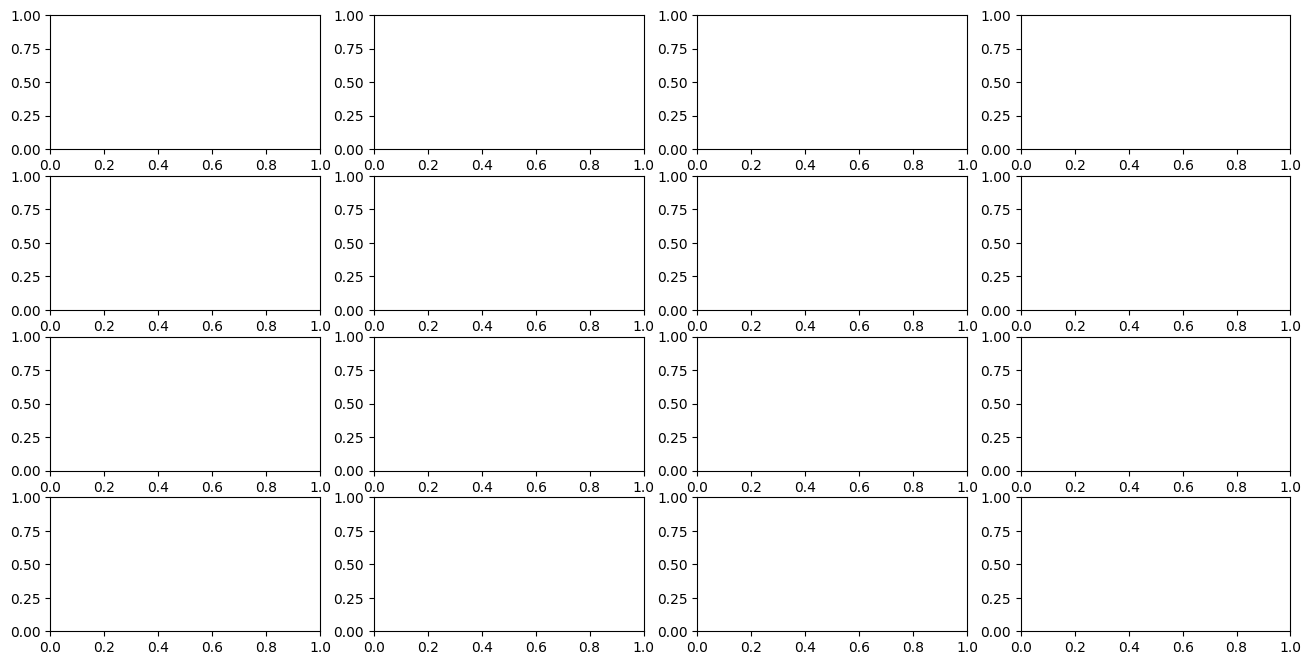

In [26]:
import matplotlib.pyplot as plt
import numpy as np

CLASS_COLORS = {
    0:   ([0.76, 0.60, 0.42], 'soil'),
    1:   ([0.50, 0.50, 0.50], 'bedrock'),
    2:   ([0.87, 0.82, 0.65], 'sand'),
    3:   ([0.60, 0.30, 0.10], 'big_rocks'),
    255: ([0.00, 0.00, 0.00], 'unknown'),
}

def label_to_color(label_np):
    h, w = label_np.shape
    color = np.zeros((h, w, 3))
    for cls_id, (col, _) in CLASS_COLORS.items():
        mask = label_np == cls_id
        color[mask] = col
    return color

# Denormalize image for display
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])
def denorm(t):
    img = t.permute(1,2,0).numpy()
    return np.clip(img * std + mean, 0, 1)

fig, axes = plt.subplots(4, 4, figsize=(16, 8))
for i in range(4):
    img_np    = denorm(imgs[i*2])
    label_np  = labels[i*2].numpy()
    color_lbl = label_to_color(label_np)

    axes[i][0].imshow(img_np)
    axes[i][0].set_title('Image')
    axes[i][0].axis('off')

    axes[i][1].imshow(color_lbl)
    axes[i][1].set_title('Label')
    axes[i][1].axis('off')

    axes[i][2].imshow(img_np)
    axes[i][2].imshow(color_lbl, alpha=0.5)
    axes[i][2].set_title('Overlay')
    axes[i][2].axis('off')

    # Class distribution for this image
    unique, counts = np.unique(label_np, return_counts=True)
    names = [CLASS_COLORS[u][1] for u in unique]
    axes[i][3].bar(names, counts, color=[CLASS_COLORS[u][0] for u in unique])
    axes[i][3].set_title('Pixel counts')
    axes[i][3].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/MarsIDAI710/sample_visualization.png', dpi=100, bbox_inches='tight')
plt.show()
print("Saved to sample_visualization.png")

In [27]:
%cd /content/MarsIDAI710
!git pull

import sys
sys.path.insert(0, '/content/MarsIDAI710')

from perception import TerrainClassifier, get_dominant_label, run_mc_dropout
import torch

# Test dominant label
fake_labels = torch.zeros(4, 256, 256, dtype=torch.long)
fake_labels[0] = 1   # all bedrock
fake_labels[1, :128] = 255  # half unknown, half soil
fake_labels[2] = 3   # all big_rocks
fake_labels[3] = 255 # all unknown → should fallback to 0
print("Dominant labels:", get_dominant_label(fake_labels).tolist())
# Expected: [1, 0, 3, 0]

# Test model forward pass
tc = TerrainClassifier()
model = tc.get_model()
dummy = torch.randn(1, 3, 256, 256)
out = model(dummy)
print("Model output shape:", out.shape)  # Expected: [1, 4]

# Test MC dropout
mean_probs, entropy, pred = run_mc_dropout(model, dummy, T=5)
print("Mean probs shape:", mean_probs.shape)  # Expected: [4]
print("Entropy shape:", entropy.shape)        # Expected: scalar
print("Pred class:", pred.item())

/content/MarsIDAI710
remote: Enumerating objects: 5, done.
remote: Counting objects: 100% (5/5), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 3 (delta 2), reused 3 (delta 2), pack-reused 0 (from 0)
Unpacking objects: 100% (3/3), 591 bytes | 591.00 KiB/s, done.
From https://github.com/aditdhall/MarsIDAI710
   a9641ae..e71103a  main       -> origin/main
Updating a9641ae..e71103a
Fast-forward
 train.py | 23 ++++++++++++++++-------
 1 file changed, 16 insertions(+), 7 deletions(-)
Dominant labels: [1, 0, 3, 0]
Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 110MB/s]


Model output shape: torch.Size([1, 4])
Mean probs shape: torch.Size([4])
Entropy shape: torch.Size([])
Pred class: 1


In [28]:
from google.colab import userdata
token = userdata.get('GITHUB_TOKEN')
!git clone https://{token}@github.com/aditdhall/MarsIDAI710.git /content/MarsIDAI710

fatal: destination path '/content/MarsIDAI710' already exists and is not an empty directory.


In [29]:
import os, json
from google.colab import userdata

os.makedirs('/root/.config/kaggle', exist_ok=True)
kaggle_creds = {
    "username": userdata.get('KAGGLE_USERNAME'),
    "key": userdata.get('KAGGLE_KEY')
}
with open('/root/.config/kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
os.chmod('/root/.config/kaggle/kaggle.json', 0o600)

!kaggle datasets download -d yash92328/ai4mars-terrainaware-autonomous-driving-on-mars --unzip -p ai4mars/
print("Done")

Dataset URL: https://www.kaggle.com/datasets/yash92328/ai4mars-terrainaware-autonomous-driving-on-mars
License(s): CC0-1.0
100% 5.72G/5.72G [00:22<00:00, 276MB/s]

User cancelled operation
Done


In [30]:
import sys
sys.path.insert(0, DRIVE)

IMG_DIR   = f'{DRIVE}/ai4mars/ai4mars-dataset-merged-0.1/msl/images/edr'
LABEL_DIR = f'{DRIVE}/ai4mars/ai4mars-dataset-merged-0.1/msl/labels/train'
GOOD_JSON = f'{DRIVE}/good_labels.json'

!python {DRIVE}/train.py --img_dir {IMG_DIR} --label_dir {LABEL_DIR} --good_json {GOOD_JSON}

Using device: cuda
Train: 12720, Val: 1590, Test: 1591
Class weights (soil, bedrock, sand, big_rocks): [2.700000047683716, 2.0, 8.300000190734863, 111.0]
Epoch 1: train_loss=0.6234 val_loss=0.4124 val_acc=0.8887
Epoch 2: train_loss=0.4423 val_loss=0.3418 val_acc=0.9044
Epoch 3: train_loss=0.3790 val_loss=0.3489 val_acc=0.8969
Epoch 4: train_loss=0.3059 val_loss=0.3609 val_acc=0.8969
Epoch 5: train_loss=0.2851 val_loss=0.3830 val_acc=0.8962
Epoch 6: train_loss=0.2460 val_loss=0.4316 val_acc=0.9082
Epoch 7: train_loss=0.2378 val_loss=0.4502 val_acc=0.8925
Epoch 8: train_loss=0.2022 val_loss=0.4276 val_acc=0.9170
Epoch 9: train_loss=0.1905 val_loss=0.5253 val_acc=0.9201
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7b7bd97867a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/da